## Make a copy and use this colab to write your final project code. Good luck!

In [ ]:
import pandas as pd
# STEP 1: Paste the URL to your chosen dataset here!
my_dataset_url = "https://www.kaggle.com/datasets/datasnaek/youtube-new"

dataset_path = my_dataset_url.split("/datasets/")[1]
print(dataset_path)

!kaggle datasets download -d $dataset_path

# Unzip the downloaded dataset
!unzip /content/youtube-new.zip -d /content/youtube_data

# List the contents of the unzipped directory to find the CSV files
!ls /content/youtube_data


# STEP 2: Use pd.read_csv() to load it into a DataFrame called 'my_data'
my_data = pd.read_csv('/content/youtube_data/USvideos.csv')

# STEP 3: Print the .head() of your data to prove it loaded successfully!
print(my_data.head())

# STEP 4: Run your "metal detector" to see if there are any missing blanks (NaNs)!
# Hint: use .isnull().sum()
print(my_data.isnull().sum())

# Fill missing values in the 'description' column with an empty string
my_data['description'] = my_data['description'].fillna('')

# Verify that there are no more missing values in the 'description' column
print(my_data['description'].isnull().sum())

datasnaek/youtube-new
Dataset URL: https://www.kaggle.com/datasets/datasnaek/youtube-new
License(s): CC0-1.0
youtube-new.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/youtube-new.zip
replace /content/youtube_data/CA_category_id.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: CA_category_id.json  GBvideos.csv	  MX_category_id.json
CAvideos.csv	     IN_category_id.json  MXvideos.csv
DE_category_id.json  INvideos.csv	  RU_category_id.json
DEvideos.csv	     JP_category_id.json  RUvideos.csv
FR_category_id.json  JPvideos.csv	  US_category_id.json
FRvideos.csv	     KR_category_id.json  USvideos.csv
GB_category_id.json  KRvideos.csv
      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOU

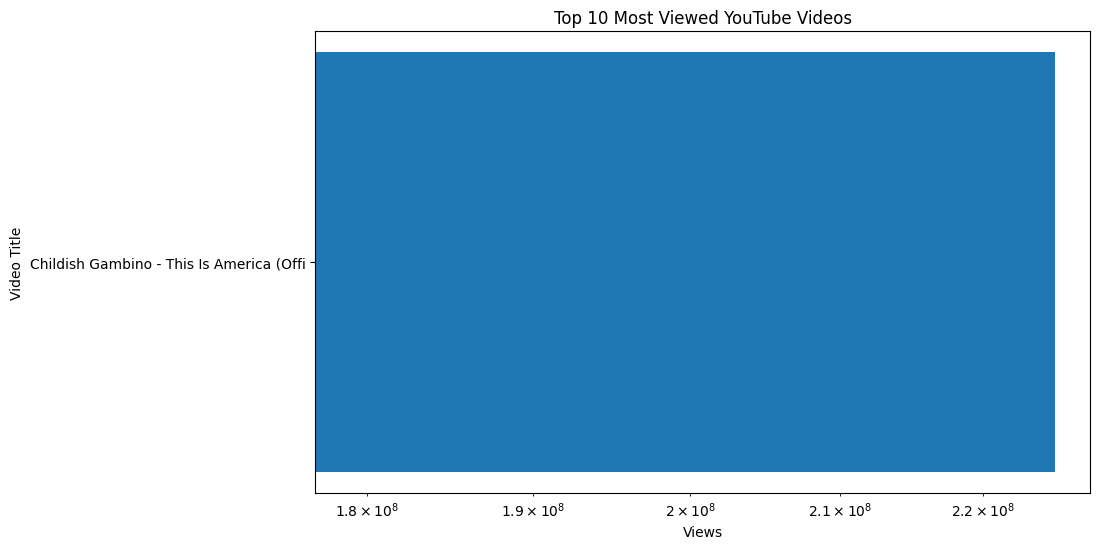

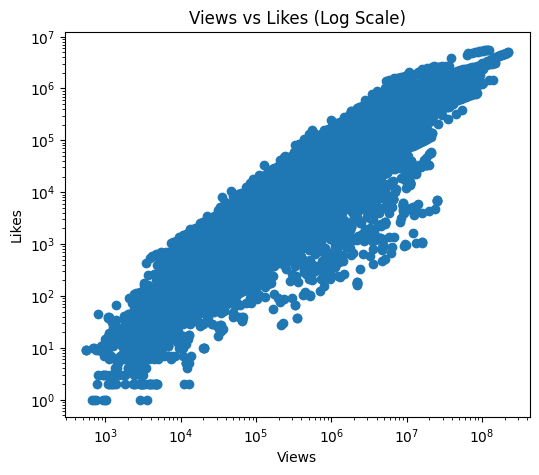

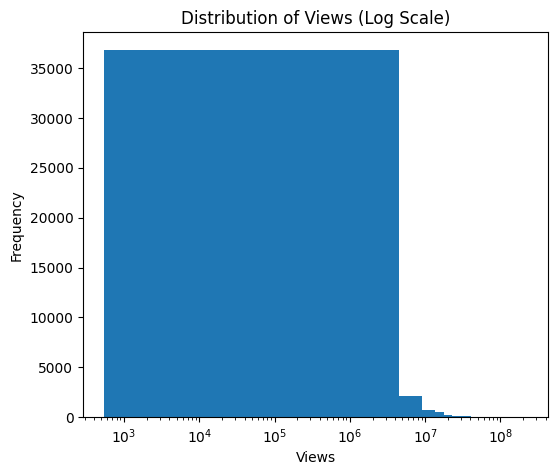

In [ ]:
import matplotlib.pyplot as plt
#Top 10 most viewed videos
top_videos = my_data.sort_values("views", ascending=False).head(10)

top_videos["short_title"] = top_videos["title"].str.slice(0, 40)
plt.figure(figsize=(10,6))
plt.barh(top_videos["short_title"], top_videos["views"])
plt.xlabel("Views")
plt.ylabel("Video Title")
plt.title("Top 10 Most Viewed YouTube Videos")
plt.xscale("log")
plt.gca().invert_yaxis()
plt.show()

#Views vs Likes
plt.figure(figsize=(6,5))
plt.scatter(my_data["views"], my_data["likes"])
plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("Views vs Likes (Log Scale)")
plt.xscale("log")
plt.yscale("log")
plt.show()




#Views Distribution
plt.figure(figsize=(6,5))
plt.hist(my_data["views"], bins=50)
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.title("Distribution of Views (Log Scale)")
plt.xscale("log")
plt.show()



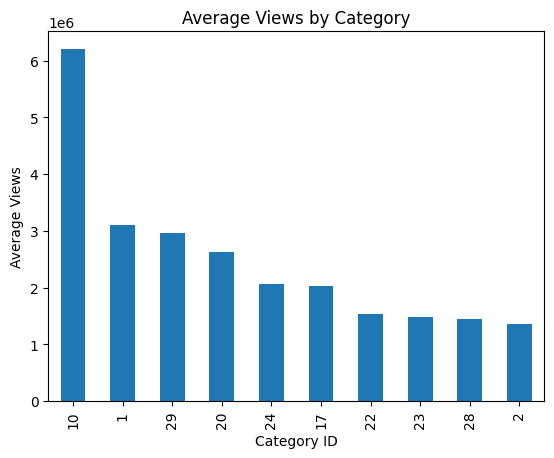

In [ ]:
#Question 1
category_views = my_data.groupby("category_id")["views"].mean().sort_values(ascending=False)
category_views.head(10)
import matplotlib.pyplot as plt
category_views.head(10).plot(kind="bar")
plt.title("Average Views by Category")
plt.xlabel("Category ID")
plt.ylabel("Average Views")
plt.show()

#Insight: Videos in certain categories receive higher average views, suggesting content type influences trending success.



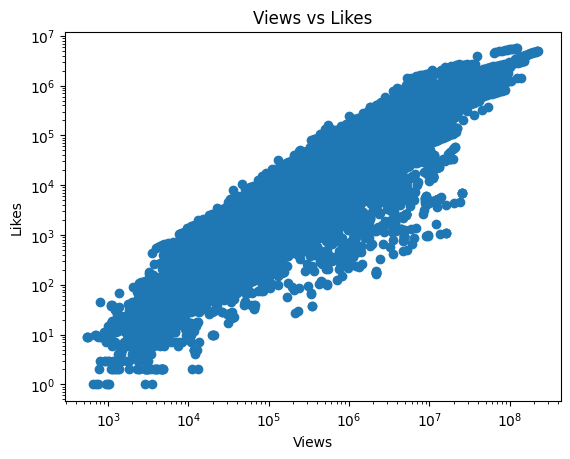

In [ ]:
#Question 2

my_data[["views", "likes"]].corr()
plt.scatter(my_data["views"], my_data["likes"])
plt.xscale("log")
plt.yscale("log")
plt.title("Views vs Likes")
plt.xlabel("Views")
plt.ylabel("Likes")
plt.show()

#Insight: There is a strong positive relationship between views and likes, proving that higher visibility leads to greater engagement.

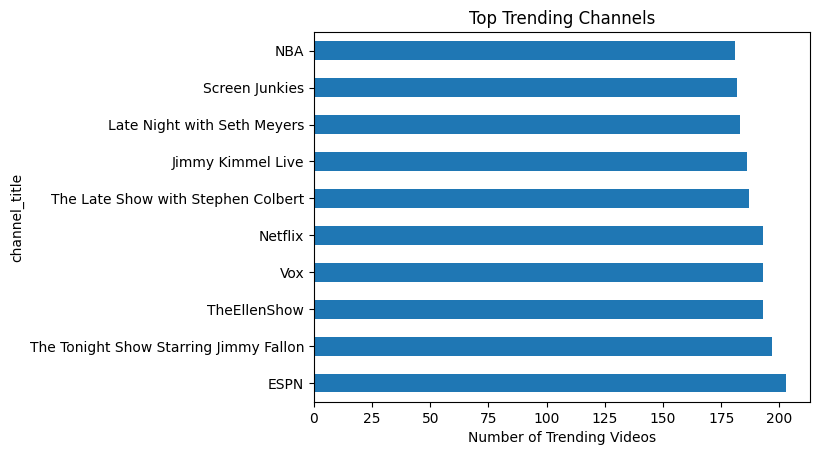

In [ ]:
#Question 3

top_channels = my_data["channel_title"].value_counts().head(10)
top_channels
top_channels.plot(kind="barh")
plt.title("Top Trending Channels")
plt.xlabel("Number of Trending Videos")
plt.show()

#Insight:A small number of channels appear frequently in trending, suggesting consistent content strategy or strong audience reach.